In [1]:
import matplotlib.pyplot as pl
import numpy as np

from astropy.io import fits
from astropy.visualization import ZScaleInterval
from petitRADTRANS import physical_constants as nc  
from petitRADTRANS.radtrans import Radtrans 
from petitRADTRANS.chemistry.pre_calculated_chemistry import PreCalculatedEquilibriumChemistryTable
from petitRADTRANS.chemistry.utils import compute_mean_molar_masses
from petitRADTRANS.physics import temperature_profile_function_guillot_global as get_tprofile, rebin_spectrum
from petitRADTRANS.chemistry.prt_molmass import get_species_molar_mass

def get_ts_model(atmosphere:Radtrans, chem:PreCalculatedEquilibriumChemistryTable, temperatures:np.ndarray, planet_mass:float=1.0, planet_radius:float=1.0, star_radius:float=1.0, ref_pres_bar:float=1e-3, cloud_pres_bar:float=1e-1, metal:float=0, c2o_ratio:float=0.55, cloud_fraction:float=1.0 ) -> np.ndarray:

    planet_mass = planet_mass * nc.m_jup # g 
    planet_radius = planet_radius * nc.r_jup_mean # cm
    star_radius = star_radius * nc.r_sun # cm
    pres_bar = atmosphere.pressures*1e-6 # cgs to bar
    
    # calculate the temperature profile
    ref_gravity = nc.G * planet_mass / planet_radius**2 
    
    # calculate chemical abundances
    c2o_ratios = np.full_like(pres_bar, c2o_ratio)
    metals = np.full_like(pres_bar, metal)
    mass_fractions = chem.interpolate_mass_fractions(
        co_ratios=c2o_ratios,
        log10_metallicities=metals,
        temperatures=temperatures,
        pressures=pres_bar,
        full=False
    )  
    mmw = compute_mean_molar_masses(mass_fractions)

    # calculate the transmission spectrum
    _, transit_radii, add_output = atmosphere.calculate_transit_radii(
        temperatures=temperatures,
        mass_fractions=mass_fractions,
        mean_molar_masses=mmw,
        reference_gravity=ref_gravity,
        planet_radius=planet_radius,
        reference_pressure=ref_pres_bar,
        opaque_cloud_top_pressure=cloud_pres_bar, 
        cloud_fraction=cloud_fraction,
    ) 

    transit_depths = (transit_radii/star_radius)**2
    return transit_depths

infile = '/home/ubuntu/work/lcretrieval/JWST_data/HD209458b/results-260421-pix/HD209458b.fits'
species_names = ["H2O", "CO", "CO2", "CH4", "NH3", "SiO", "C2H2", "HCN"]

planet_radius = 1.39 # R_jup
star_radius = 1.19 # R_sun 
teq = 1459.0 # K

atmosphere = Radtrans(
            pressures = np.logspace(-10, 2, 121),
            line_species = species_names, 
            rayleigh_species = ['H2', 'He'],
            gas_continuum_contributors = ['H2--H2', 'H2--He'],
            wavelength_boundaries = [2.5, 5.0],
            line_opacity_mode = 'lbl', )
wavelengths = 1e4 * atmosphere.get_wavelengths() # from cm to micron
pres_bar = atmosphere.pressures*1e-6 # cgs to bar

chem = PreCalculatedEquilibriumChemistryTable()

Loading Radtrans opacities...
 Loading line opacities of species 'H2O' from file '/home/ubuntu/petitRADTRANS/input_data/opacities/lines/line_by_line/H2O/1H2-16O/1H2-16O__POKAZATEL.R15000_0.3-50mu.xsec.TauREx.h5'... Done.
 Loading line opacities of species 'CO' from file '/home/ubuntu/petitRADTRANS/input_data/opacities/lines/line_by_line/CO/12C-16O/12C-16O__Li2015.R15000_0.3-50mu.xsec.TauREx.h5'... Done.
 Loading line opacities of species 'CO2' from file '/home/ubuntu/petitRADTRANS/input_data/opacities/lines/line_by_line/CO2/12C-16O2/12C-16O2__UCL-4000.R15000_0.3-50mu.xsec.TauREx.h5'... Done.
 Loading line opacities of species 'CH4' from file '/home/ubuntu/petitRADTRANS/input_data/opacities/lines/line_by_line/CH4/12C-1H4/12C-1H4__MM.R15000_0.3-50mu.xsec.TauREx.h5'... Done.
 Loading line opacities of species 'NH3' from file '/home/ubuntu/petitRADTRANS/input_data/opacities/lines/line_by_line/NH3/14N-1H3/14N-1H3__CoYuTe.R15000_0.3-50mu.xsec.TauREx.h5'... Done.
 Loading line opacities of sp

In [2]:
hdul = fits.open(infile)
postsamples = hdul['MCMC'].data
atm_params = np.array([
    postsamples['mp'],
    postsamples['ref_p'],
    postsamples['cloud_p'],
    postsamples['kir'],
    postsamples['gamma'],
    postsamples['tint'],
    postsamples['m2h'],
    postsamples['c2o'], 
])
atm_params = atm_params.T 

In [3]:
planet_mass = 0.828351 * nc.m_jup # g  
ref_pres_bar = 10**1.46217
cloud_pres_bar = 10**-0.989519
metals = np.full_like(pres_bar, 1.68743)
c2o_ratios = np.full_like(pres_bar, 0.101954)
ref_gravity = nc.G * planet_mass / (planet_radius * nc.r_jup_mean)**2 
cloud_fraction = 1.0

# temperatures = np.full_like(pres_bar, 1488.0) # K 
temperatures = get_tprofile(
    pressures=pres_bar,
    infrared_mean_opacity=10**-3.43477,
    gamma=10**0.154312,
    gravities=ref_gravity,
    intrinsic_temperature=464.207,
    equilibrium_temperature=teq,
)

# calculate chemical abundances
mass_fractions = chem.interpolate_mass_fractions(
    co_ratios=c2o_ratios,
    log10_metallicities=metals,
    temperatures=temperatures,
    pressures=pres_bar,
    full=False
)  

mmw = compute_mean_molar_masses(mass_fractions)

# calculate the transmission spectrum
_, transit_radii, add_output = atmosphere.calculate_transit_radii(
    temperatures=temperatures,
    mass_fractions=mass_fractions,
    mean_molar_masses=mmw,
    reference_gravity=ref_gravity,
    planet_radius=planet_radius * nc.r_jup_mean,
    reference_pressure=ref_pres_bar,
    opaque_cloud_top_pressure=cloud_pres_bar, 
    cloud_fraction=cloud_fraction,
    return_contribution=True,
) 
ts_bestfit = (transit_radii/(star_radius * nc.r_sun))**2
contributions = add_output['transmission_contribution']

Loading chemical equilibrium chemistry table from file '/home/ubuntu/petitRADTRANS/input_data/pre_calculated_chemistry/equilibrium_chemistry/equilibrium_chemistry.chemtable.petitRADTRANS.h5'... Done.


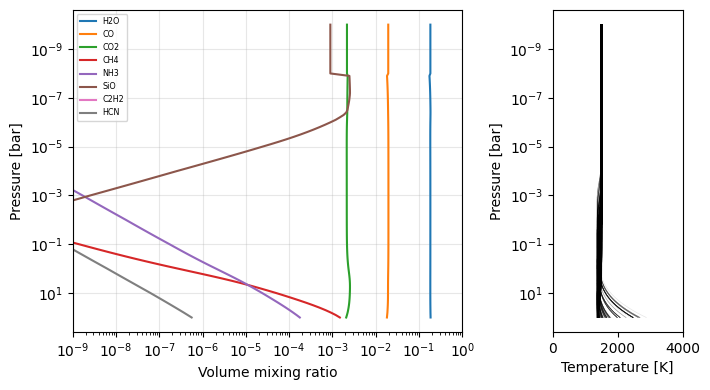

In [4]:
fig, ax = pl.subplots(1, 2, figsize=(7.2, 4), gridspec_kw={'width_ratios': [3, 1]})

for i, sp in enumerate(species_names):
    mixing_ratios = mass_fractions[sp] * mmw / get_species_molar_mass(sp)
    ax[0].plot(mixing_ratios, pres_bar, label=sp)

# Literature values
# c2o_ratios = np.full_like(pres_bar, 0.23)
# metals = np.full_like(pres_bar, 0.69)
# mass_fractions, mmw, nabla_ad = chem.interpolate_mass_fractions(
#     co_ratios=c2o_ratios,
#     log10_metallicities=metals,
#     temperatures=temperatures,
#     pressures=pres_bar,
#     full=True
#     )  
# for i, sp in enumerate(species_names):
#     mixing_ratios = mass_fractions[sp] * mmw / get_species_molar_mass(sp)
#     ax[0].plot(mixing_ratios, pres_bar, ls='--', c=f'C{i}') 

for p in atm_params[-1000:]:
    kir = p[3]
    gamma = p[4]
    tint = p[5]
    temp = get_tprofile(
        pressures=pres_bar,
        infrared_mean_opacity=10**kir,
        gamma=10**gamma,
        gravities=ref_gravity,
        intrinsic_temperature=tint,
        equilibrium_temperature=teq,
    )
    ax[1].plot(temp, pres_bar, lw=0.5, alpha=0.1, c='k')

ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].set_ylabel('Pressure [bar]')
ax[0].set_xlabel('Volume mixing ratio')
ax[0].set_xlim(1e-9, 1) 
ax[0].grid(alpha=0.3)
ax[0].invert_yaxis()
ax[0].legend(fontsize='xx-small')

ax[1].set_xlim(0, 4000)
ax[1].set_xlabel('Temperature [K]')
ax[1].set_yscale('log') 
ax[1].set_ylabel('Pressure [bar]')
ax[1].invert_yaxis()
fig.tight_layout()
fig.savefig('chemistry.png', dpi=100)

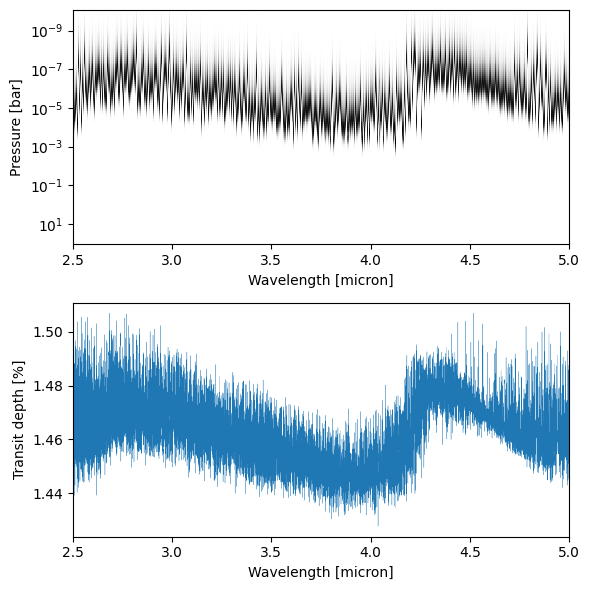

In [5]:
""" Contribution function """

fig, ax = pl.subplots(2, 1, figsize=(6,6),) 

zscale = ZScaleInterval(contrast=0.03)
vmin, vmax = zscale.get_limits(contributions)
a = ax[0].pcolormesh(wavelengths, pres_bar, contributions, shading='auto', vmin=vmin, vmax=vmax, cmap='gray_r')
ax[0].set_xlabel('Wavelength [micron]')
ax[0].set_ylabel('Pressure [bar]')
ax[0].set_yscale('log') 
ax[0].invert_yaxis()
# fig.colorbar(a, ax=ax[0], label="Contribution function")

ax[1].plot(wavelengths, ts_bestfit*100, lw=0.2, zorder=0)  
ax[1].set_xlim(ax[0].get_xlim()) 
ax[1].set_xlabel('Wavelength [micron]')
ax[1].set_ylabel('Transit depth [%]')

fig.tight_layout()
fig.savefig('contribution_function.png', dpi=100)

In [6]:
ts_samples = [] 
np.random.seed(42)
np.random.shuffle(atm_params)
sub_samples = atm_params[:200] 
for i, s in enumerate(sub_samples): 
    # temperatures = np.full_like(pres_bar, s[3]) # K 
    temperatures = get_tprofile(
        pressures=pres_bar,
        infrared_mean_opacity=10**s[3],
        gamma=10**s[4],
        gravities=ref_gravity,
        intrinsic_temperature=s[5],
        equilibrium_temperature=teq,
    )
    
    _ts = get_ts_model( 
        atmosphere=atmosphere, 
        chem=chem, 
        temperatures=temperatures, 
        planet_radius=planet_radius, 
        star_radius=star_radius, 
        planet_mass=s[0], 
        ref_pres_bar=10**s[1], 
        cloud_pres_bar=10**s[2], 
        metal=s[6], 
        c2o_ratio=s[7], 
    )

    ts_samples.append(_ts)


In [8]:
wl_start, wl_end, resolution = 2.52, 4.98, 1600
len_wl = np.log(wl_end / wl_start) * resolution
len_wl = int(np.round(len_wl))
wl_rebinned = np.logspace(np.log10(wl_start), np.log10(wl_end), len_wl)
ts_rebinned = np.array([rebin_spectrum(wavelengths, _s, wl_rebinned) for _s in ts_samples])

ts_median = np.median(ts_rebinned, axis=0)
ts_error = np.std(ts_rebinned, axis=0)
ts_up = np.percentile(ts_rebinned, 99.865, axis=0)
ts_lo = np.percentile(ts_rebinned, 0.135, axis=0)

ts_bestfit_rebinned = rebin_spectrum(wavelengths, ts_bestfit, wl_rebinned)


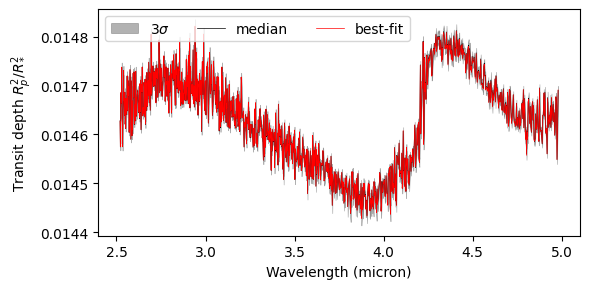

In [9]:
fig, ax = pl.subplots(1,1, figsize=(6, 3)) 
ax.fill_between(wl_rebinned, ts_lo, ts_up, 
    color='k', alpha=0.3, lw=0.5, zorder=1, label=r'3$\sigma$') 
ax.plot(wl_rebinned, ts_median, lw=0.5, label='median', color='k', zorder=3) 
ax.plot(wl_rebinned, ts_bestfit_rebinned, lw=0.5, label='best-fit', color='r', zorder=4) 
ax.set_xlabel('Wavelength (micron)')
ax.set_ylabel('Transit depth $R_p^2/R_*^2$')
ax.legend(ncol=3, loc='upper left')
fig.tight_layout()
fig.savefig('post_spectrum.png', dpi=100)